# Experimento de Clasificación Multiclase
## Predicción del Método Anticonceptivo (Contraceptive Method Choice Dataset)

**Problema:** Predecir el método anticonceptivo utilizado actualmente por una mujer
en función de sus características demográficas y socioeconómicas.

| Clase | Descripción |
|-------|-------------|
| 1 | Sin uso de anticonceptivo |
| 2 | Uso de anticonceptivo de larga duración |
| 3 | Uso de anticonceptivo de corta duración |

---
## Flujo del Experimento
1. División de datos
2. Preprocesamiento
3. Entrenamiento con Validación Cruzada 
4. Evaluación con métricas de comparación

---
## Parte 1: División de Datos

El conjunto de datos se divide en tres subconjuntos:
- **Entrenamiento (60%):** para ajustar los modelos.
- **Validación (20%):** para selección de hiperparámetros con validación cruzada.
- **Prueba (20%):** para evaluación final e imparcial del modelo.

Se aplica **estratificación** (`stratify=y`) para garantizar que la proporción
de las tres clases se mantenga constante en todos los subconjuntos.

### 1.1 Instalación de dependencias

In [1]:
%pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1.2 Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1.3 Carga del dataset desde UCI

In [3]:
cmc = fetch_ucirepo(id=30)
X = cmc.data.features
y = cmc.data.targets.squeeze()

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (1473, 9)
Dimensiones de y: (1473,)


### 1.4 División estratificada: Entrenamiento / Validación / Prueba

La división se realiza en **dos pasos**:
1. Separar el 20 % de prueba del 80 % restante.
2. Del 80 % restante, separar el 25 % como validación (= 20 % del total)
   y conservar el 75 % como entrenamiento (= 60 % del total).

In [4]:
# Paso 1: separar prueba (20 %)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Paso 2: separar validación (25 % de X_temp = 20 % del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print("División de datos completada:")
print(f"  Entrenamiento : {len(X_train):>5} muestras ({len(X_train)/len(X)*100:.1f} %)")
print(f"  Validación    : {len(X_val):>5} muestras ({len(X_val)/len(X)*100:.1f} %)")
print(f"  Prueba        : {len(X_test):>5} muestras ({len(X_test)/len(X)*100:.1f} %)")
print(f"  Total         : {len(X_train)+len(X_val)+len(X_test):>5} muestras")

División de datos completada:
  Entrenamiento :   883 muestras (59.9 %)
  Validación    :   295 muestras (20.0 %)
  Prueba        :   295 muestras (20.0 %)
  Total         :  1473 muestras


### 1.5 Verificación de la estratificación

In [5]:
def distribucion_clases(y_serie, nombre):
    conteo = y_serie.value_counts().sort_index()
    return pd.DataFrame({
        'Conjunto': nombre,
        'Clase': conteo.index,
        'Conteo': conteo.values,
        'Porcentaje (%)': (conteo.values / len(y_serie) * 100).round(2)
    })

tabla = pd.concat([
    distribucion_clases(y, 'Total'),
    distribucion_clases(y_train, 'Entrenamiento (60%)'),
    distribucion_clases(y_val,   'Validación (20%)'),
    distribucion_clases(y_test,  'Prueba (20%)')
], ignore_index=True)

tabla_pivot = tabla.pivot(index='Clase', columns='Conjunto', values='Porcentaje (%)')
tabla_pivot.index = ['Clase 1 (Sin uso)', 'Clase 2 (Larga dur.)', 'Clase 3 (Corta dur.)']
tabla_pivot.columns.name = 'Porcentaje (%) por conjunto'
tabla_pivot = tabla_pivot[['Total', 'Entrenamiento (60%)', 'Validación (20%)', 'Prueba (20%)']]

print("Distribución porcentual de clases por subconjunto:")
tabla_pivot

Distribución porcentual de clases por subconjunto:


Porcentaje (%) por conjunto,Total,Entrenamiento (60%),Validación (20%),Prueba (20%)
Clase 1 (Sin uso),42.70,42.70,42.71,42.71
Clase 2 (Larga dur.),22.61,22.54,22.71,22.71
Clase 3 (Corta dur.),34.69,34.77,34.58,34.58


### 1.6 Visualización de la distribución por subconjunto

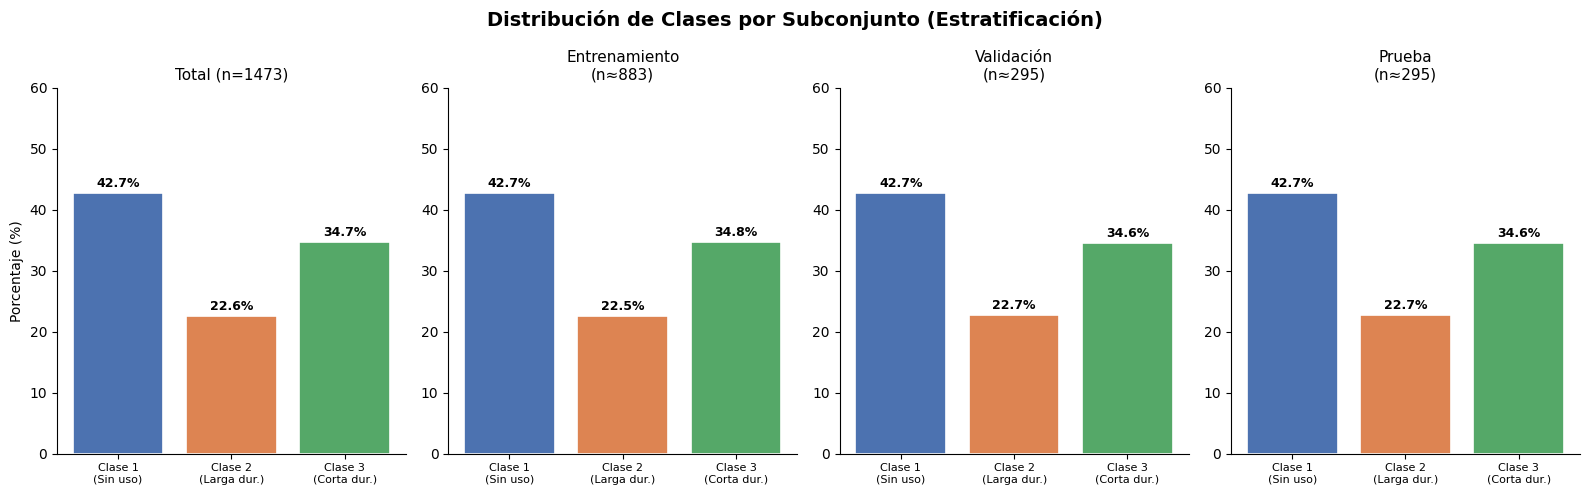

In [6]:
etiquetas_clases = {1: 'Clase 1\n(Sin uso)', 2: 'Clase 2\n(Larga dur.)', 3: 'Clase 3\n(Corta dur.)'}
colores = ['#4C72B0', '#DD8452', '#55A868']
conjuntos = {
    'Total (n=1473)': y,
    'Entrenamiento\n(n≈883)': y_train,
    'Validación\n(n≈295)': y_val,
    'Prueba\n(n≈295)': y_test
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.suptitle('Distribución de Clases por Subconjunto (Estratificación)', fontsize=14, fontweight='bold')

for ax, (titulo, serie) in zip(axes, conjuntos.items()):
    conteo = serie.value_counts().sort_index()
    pcts = conteo.values / len(serie) * 100
    bars = ax.bar([etiquetas_clases[c] for c in conteo.index], pcts, color=colores, edgecolor='white', linewidth=1.2)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Porcentaje (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 60)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

### 1.7 Resumen final de la división

In [7]:
resumen = pd.DataFrame({
    'Subconjunto': ['Entrenamiento', 'Validación', 'Prueba', 'TOTAL'],
    'Muestras': [len(X_train), len(X_val), len(X_test), len(X_train)+len(X_val)+len(X_test)],
    'Porcentaje (%)': [
        round(len(X_train)/len(X)*100, 1), round(len(X_val)/len(X)*100, 1),
        round(len(X_test)/len(X)*100, 1), 100.0
    ],
    'Uso': ['Ajuste de parámetros del modelo', 'Selección de hiperparámetros (CV)',
            'Evaluación final imparcial', '—']
})

print(f"Semilla de reproducibilidad: RANDOM_STATE = {RANDOM_STATE}")
print("Estratificación aplicada: stratify=y en ambas divisiones\n")
resumen

Semilla de reproducibilidad: RANDOM_STATE = 42
Estratificación aplicada: stratify=y en ambas divisiones



,Subconjunto,Muestras,Porcentaje (%),Uso
0,Entrenamiento,883,59.9,Ajuste de parámetros del modelo
1,Validación,295,20.0,Selección de hiperparámetros (CV)
2,Prueba,295,20.0,Evaluación final imparcial
3,TOTAL,1473,100.0,—


---
## Parte 2: Preprocesamiento

Para asegurar la consistencia entre entrenamiento y evaluación, se construye
un **pipeline de preprocesamiento** con dos transformaciones:

| Transformación | Variables aplicadas | Justificación |
|---|---|---|
| `StandardScaler` | `wife_age`, `num_children` | Variables numéricas continuas con distintas escalas |
| `OneHotEncoder` | `wife_edu`, `husband_occupation` | Variables categóricas ordinales tratadas como nominales |

> **Importante:** el preprocesador se ajusta **solo sobre X_train** (`fit_transform`)
> y se aplica en X_val y X_test (`transform`), evitando *data leakage*.

### 2.1 Importación de herramientas de preprocesamiento

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Herramientas de preprocesamiento importadas correctamente.")

Herramientas de preprocesamiento importadas correctamente.


### 2.2 Definición de variables por tipo

Se clasifican las 9 variables de entrada según el tratamiento que recibirán:

In [9]:
# Variables numéricas: se aplicará StandardScaler
vars_numericas = ['wife_age', 'num_children']

# Variables categóricas: se aplicará OneHotEncoding
vars_categoricas = ['wife_edu', 'husband_occupation']

# Variables que se pasan sin transformar (binarias / ordinales de bajo rango)
vars_passthrough = ['husband_edu', 'wife_religion', 'wife_working',
                    'standard_of_living_index', 'media_exposure']

# Resumen
resumen_vars = pd.DataFrame({
    'Variable': vars_numericas + vars_categoricas + vars_passthrough,
    'Transformación': (['StandardScaler'] * len(vars_numericas) +
                       ['OneHotEncoder'] * len(vars_categoricas) +
                       ['Sin cambio (passthrough)'] * len(vars_passthrough))
})
resumen_vars

,Variable,Transformación
0,wife_age,StandardScaler
1,num_children,StandardScaler
2,wife_edu,OneHotEncoder
3,husband_occupation,OneHotEncoder
4,husband_edu,Sin cambio (passthrough)
5,wife_religion,Sin cambio (passthrough)
6,wife_working,Sin cambio (passthrough)
7,standard_of_living_index,Sin cambio (passthrough)
8,media_exposure,Sin cambio (passthrough)


### 2.3 Construcción del preprocesador con ColumnTransformer

In [10]:
# Pipeline para variables numéricas
pipe_numerica = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
pipe_categorica = Pipeline(steps=[
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer: aplica cada pipeline a sus variables correspondientes
preprocessor = ColumnTransformer(transformers=[
    ('num', pipe_numerica,  vars_numericas),
    ('cat', pipe_categorica, vars_categoricas),
    ('pass', 'passthrough', vars_passthrough)
])

print("Preprocesador definido correctamente.")
print(preprocessor)

Preprocesador definido correctamente.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['wife_age', 'num_children']),
                                ('cat',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['wife_edu', 'husband_occupation']),
                                ('pass', 'passthrough',
                                 ['husband_edu', 'wife_religion',
                                  'wife_working', 'standard_of_living_index',
                                  'media_exposure'])])


### 2.4 Ajuste y transformación de los conjuntos

- `fit_transform` solo sobre **X_train** → el escalador y el OHE aprenden de los datos de entrenamiento.
- `transform` sobre **X_val** y **X_test** → se aplican los parámetros aprendidos sin reajustar.

In [11]:
# Ajuste SOLO en entrenamiento y transformación de los tres conjuntos
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print("Dimensiones tras el preprocesamiento:")
print(f"  X_train_proc : {X_train_proc.shape}")
print(f"  X_val_proc   : {X_val_proc.shape}")
print(f"  X_test_proc  : {X_test_proc.shape}")

Dimensiones tras el preprocesamiento:
  X_train_proc : (883, 15)
  X_val_proc   : (295, 15)
  X_test_proc  : (295, 15)


### 2.5 Nombres de columnas resultantes

El OHE genera múltiples columnas por variable categórica.
Se identifican todas las columnas del array transformado:

In [12]:
# Recuperar nombres de columnas OHE
ohe_feature_names = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(vars_categoricas)

# Lista completa de columnas en el mismo orden que el ColumnTransformer
columnas_procesadas = vars_numericas + list(ohe_feature_names) + vars_passthrough

# Mostrar como tabla
df_columnas = pd.DataFrame({
    'Índice': range(len(columnas_procesadas)),
    'Columna resultante': columnas_procesadas,
    'Origen': (['StandardScaler'] * len(vars_numericas) +
               ['OneHotEncoder'] * len(ohe_feature_names) +
               ['Passthrough'] * len(vars_passthrough))
})
print(f"Total de columnas tras preprocesamiento: {len(columnas_procesadas)}")
df_columnas

Total de columnas tras preprocesamiento: 15


,Índice,Columna resultante,Origen
0,0,wife_age,StandardScaler
1,1,num_children,StandardScaler
2,2,wife_edu_1,OneHotEncoder
3,3,wife_edu_2,OneHotEncoder
4,4,wife_edu_3,OneHotEncoder
5,5,wife_edu_4,OneHotEncoder
6,6,husband_occupation_1,OneHotEncoder
7,7,husband_occupation_2,OneHotEncoder
8,8,husband_occupation_3,OneHotEncoder
9,9,husband_occupation_4,OneHotEncoder


### 2.6 Verificación: primeras filas del conjunto de entrenamiento procesado

In [13]:
# Convertir a DataFrame para facilitar la lectura
df_train_proc = pd.DataFrame(X_train_proc, columns=columnas_procesadas)
df_train_proc.head()

,wife_age,num_children,wife_edu_1,wife_edu_2,wife_edu_3,wife_edu_4,husband_occupation_1,husband_occupation_2,husband_occupation_3,husband_occupation_4,husband_edu,wife_religion,wife_working,standard_of_living_index,media_exposure
0,1.507180,1.968444,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0,1.0
1,1.385096,0.302366,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,3.0,1.0
2,-0.568251,-0.114154,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,1.0,4.0,0.0
3,0.896759,-0.530673,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,0.0,1.0,4.0,0.0
4,1.873432,1.968444,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,1.0,3.0,0.0


### 2.7 Estadísticas del escalado

Se verifica que `StandardScaler` funcionó correctamente:
las variables numéricas deben tener **media ≈ 0** y **desv. típica ≈ 1** en entrenamiento.

In [14]:
stats_escalado = pd.DataFrame({
    'Variable': vars_numericas,
    'Media original (train)': [
        X_train[v].mean() for v in vars_numericas
    ],
    'Desv. típica original (train)': [
        X_train[v].std() for v in vars_numericas
    ],
    'Media escalada (train)': [
        df_train_proc[v].mean() for v in vars_numericas
    ],
    'Desv. típica escalada (train)': [
        df_train_proc[v].std() for v in vars_numericas
    ]
})
stats_escalado = stats_escalado.round(4)
stats_escalado

,Variable,Media original (train),Desv. típica original (train),Media escalada (train),Desv. típica escalada (train)
0,wife_age,32.6546,8.1957,0.0,1.0006
1,num_children,3.2741,2.4022,0.0,1.0006
